# Prac 05

In this homework you are going to implement the **Floyd-Steinberg dithering** algorithm. Dithering, in general, means that we are adding noise to the signal (in our case digital image) in order to perceive it better. In other words, by adding the noise the objective quality will be worse but the subjective quality will be better (i.e. the image will "look" better).

The details of FS dithering can be found in this [wiki](https://en.wikipedia.org/wiki/Floyd%E2%80%93Steinberg_dithering) page. In order to implement the dithering, we will implement the following steps:
* Define colour pallette
* Quantize the image to obtain the baseline and compute the average quantization error
* Implement FS dithering and compute the average quantization error

You will also have to answer the question at the end of this notebook.

Note: In this homework, you will have the chance to earn some extra points. See the "Bonus" section at the end of the notebook. Good luck!

As always, you are encouraged to use your own images :-)

In [1]:
import cv2
import math
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

In [13]:
def read_image(image_path: str, plot: bool = False) -> np.ndarray:
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    if plot:
        plt.imshow(img)
        plt.show()
    return img

def show_compare(images: list, image_names: list = [], special_cmap: dict = {}):
    count = len(images)
    count_names = len(image_names)
    fig, axes = plt.subplots(1, count)
    if count == 1:
        axes = [axes]
    for cnt in range(count):
        if cnt in special_cmap or -(count - cnt) in special_cmap:
            axes[cnt].imshow(images[cnt], cmap=special_cmap.get(cnt, special_cmap.get(-(count - cnt))))
        else:
            axes[cnt].imshow(images[cnt])
        axes[cnt].axis('off')
        if cnt < count_names:
            axes[cnt].set_title(image_names[cnt])
    plt.show()

In [14]:
def scale(image: np.ndarray) -> np.ndarray:
    minimum = np.min(image)
    filtered = (255*(image - minimum)/np.ptp(image)).astype(np.uint8)
    return filtered

    
def clip(image: np.ndarray) -> np.ndarray:
    filtered = np.clip(image, 0, 255).astype(np.uint8)
    return filtered

def final_remake_to_image(image: np.ndarray, kernel: np.ndarray, print_do: bool = False) -> np.ndarray:
    sharpen = np.array([
        [-1, -1, -1,],
        [-1, 9, -1,],
        [-1, -1, -1,],
    ])
    if kernel is not None and (np.sum(kernel) == 0 or (kernel.shape == sharpen.shape and np.all(kernel  == sharpen))):
        if print_do:
            print("Cliping array...")
        filtered = clip(image)
    else:
        if print_do:
            print("Scaling array...")
        filtered = scale(image)
    return filtered


def _sum(windows: np.ndarray, kernel: np.ndarray, *args) -> np.ndarray:
    return np.sum(windows * kernel, axis=(2, 3))

def _median(windows: np.ndarray, *args) -> np.ndarray:
    return np.median(windows, axis=(2,3))

def _erosion(windows: np.ndarray, *args) -> np.ndarray:
    return np.min(windows, axis=(2,3))

def _dilation(windows: np.ndarray, *args) -> np.ndarray:
    return np.max(windows, axis=(2,3))


realizations = {
    "sum": _sum,
    "median": _median,
    "erosion": _erosion,
    "dilation": _dilation,
}
def apply_kernel_filter(image: np.ndarray, kernel: np.ndarray = None, special_move: str = "sum", print_do: bool = False) -> np.ndarray:
    special_move = realizations.get(special_move)

    if special_move:
        if len(image.shape) == 2:
            H, W = image.shape
            C = None
        elif len(image.shape) == 3:
            H, W, C = image.shape
        else:
            raise TypeError("[!] HxW or HxVxC needed")

        if kernel is not None:
            kh, kw = kernel.shape
        else:
            kh, kw = 3, 3

        pad_h = kh//2
        pad_v = kw//2
        padded = ((pad_h, pad_h), (pad_v, pad_v), (0, 0))
        if len(image.shape) == 2:
            padded = padded[:-1]
        image_padded = np.pad(image, padded, mode='edge')
        image_with_kernel = np.zeros_like(image, dtype=np.float32)
        if C:
            for ch in range(C):
                windows = np.zeros((H, W, kh, kw), dtype=np.float32)
                for i in range(kh):
                    for j in range(kw):
                        windows[:, :, i, j] = image_padded[i:i+H, j:j+W, ch]

                image_with_kernel[..., ch] = special_move(windows, kernel)
        else:
            windows = np.zeros((H, W, kh, kw), dtype=np.float32)
            for i in range(kh):
                for j in range(kw):
                    windows[:, :, i, j] = image_padded[i:i+H, j:j+W]

            image_with_kernel[...] = special_move(windows, kernel)

        return final_remake_to_image(image_with_kernel, kernel, print_do)
    return image


In [15]:
def quantization(image: np.ndarray, colors: np.ndarray) -> np.ndarray:
    diff = image[:, :, None, :] - colors[None, None, :, :]
    distances = np.linalg.norm(diff, axis=3)
    nearest = np.argmin(distances, axis=2)
    quantized = colors[nearest]
    return quantized.astype(np.uint8)

def dithering(image: np.ndarray, colors: np.ndarray) -> np.ndarray:

    rows, cols, channels = image.shape
    # Make a temporal copy of the original image, we will need it for error diffusion
    img_tmp = image.astype(np.float32)
    dither = np.zeros_like(img_tmp)

    for r in range(1, rows-1):
        for c in range(1, cols-1):
            # Extract the original pixel value
            pixel = img_tmp[r, c]
            # Find the closest colour from the pallette (using absolute value/Euclidean distance)
            # Note: You may need more than one line of code here
            diffs = colors - pixel
            dists = np.linalg.norm(diffs, axis=1)
            new_pixel = colors[np.argmin(dists)].astype(float)
            
            # Compute quantization error
            quant_error = (pixel - new_pixel).mean()
            
            # Diffuse the quantization error accroding to the FS diffusion matrix
            # Note: You may need more than one line of code here
            img_tmp[r + 1][c] = img_tmp[r + 1][c] + quant_error * 7 / 16
            img_tmp[r - 1][c + 1] = img_tmp[r - 1][c + 1] + quant_error * 3 / 16
            img_tmp[r][c + 1] = img_tmp[r][c + 1] + quant_error * 5 / 16
            img_tmp[r + 1][c + 1] = img_tmp[r + 1][c + 1] + quant_error * 1 / 16
            
            # Apply dithering
            dither[r, c, :] = new_pixel

    # quantized = quantization(image, colors)
    # error_q = image - quantized  # keep per-channel
    # # Apply kernel filter per channel (or implement FS manually)
    # error_d = apply_kernel_filter(error_q.astype(np.float32), np.array([[0, 0, 7/16], [3/16, 5/16, 1/16]]))
    # dither = np.clip(quantized + error_d, 0, 255).astype(np.uint8)
    return dither.astype(np.uint8)



Let's load the image.

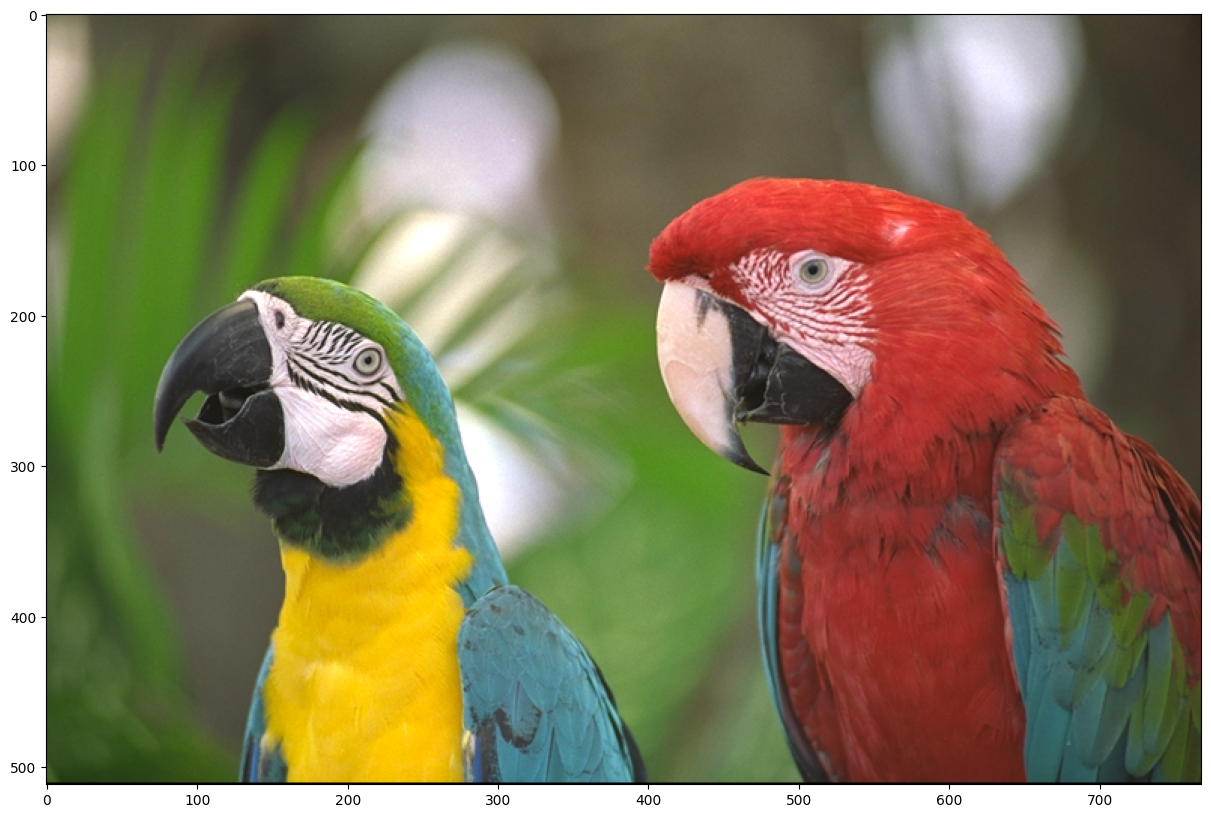

In [16]:
# Load image
img = cv2.imread('../Data/kodim23.png')
# Convert it to RGB
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
# Plot it
plt.imshow(img)

Let's start with gray tones first.

In [17]:
# Black, dark gray, light gray, white
colors = np.array([
    [0, 0, 0],
    [64, 64, 64],
    [192, 192, 192],
    [255, 255, 255]
])

Using the colour pallette, let's quantize the original image.

[AVERAGE] MAE: 136.34407128228082


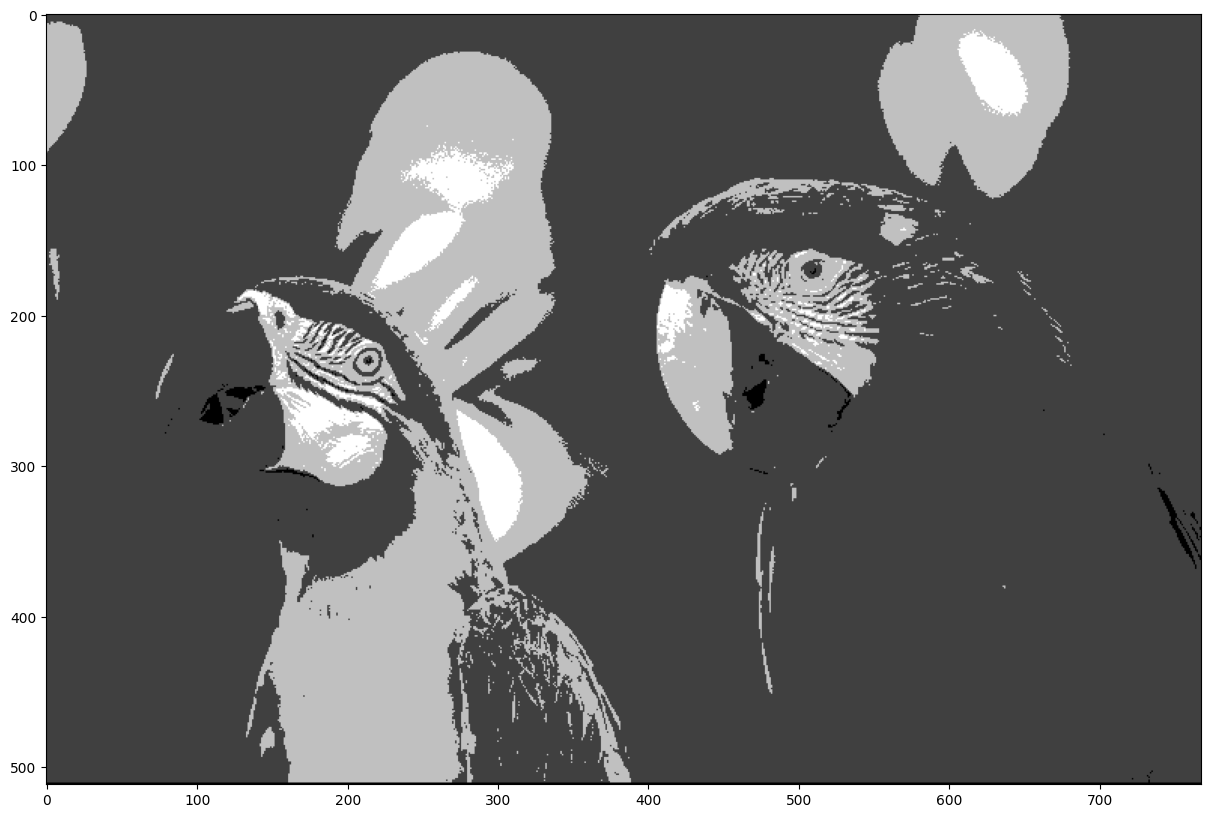

In [18]:
quantized = quantization(img, colors)

# Compute average quantization error
avg_quant_error = np.mean(np.abs(quantized - img))
print("[AVERAGE] MAE:", avg_quant_error)

plt.imshow(quantized)
plt.show()

#### Floyd-Steinberg Dithering
We are now going to implement the FS dithering and compare it to the optimally quantized image we have calculated above.

[AVERAGE] MAE: 132.16438886854382


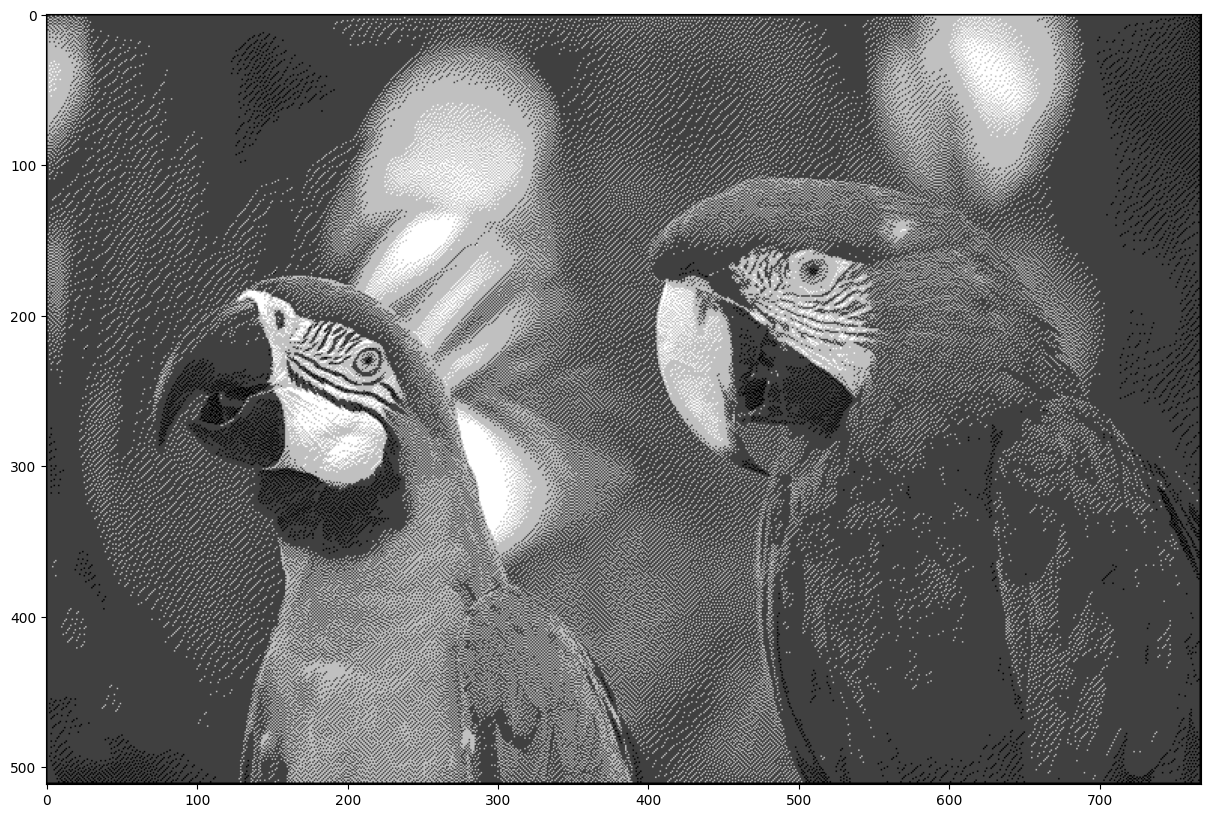

In [19]:
# Make a temporal copy of the original image, we will need it for error diffusion
# img_tmp = np.copy(img)
# dithering = np.zeros_like(img)

# for r in range(1, rows-1):
#     for c in range(1, cols-1):
#         # Extract the original pixel value
#         pixel =
#         # Find the closest colour from the pallette (using absolute value/Euclidean distance)
#         # Note: You may need more than one line of code here
#         new_pixel =         
        
#         # Compute quantization error
#         quant_error =
        
#         # Diffuse the quantization error accroding to the FS diffusion matrix
#         # Note: You may need more than one line of code here
#         img_tmp = 
        
#         # Apply dithering
#         dithering[r, c, :] = new_pixel


dither = dithering(img, colors)

# Compute average quantization error for dithered image
avg_dith_error = np.mean(np.abs(dither - img))
print("[AVERAGE] MAE:", avg_dith_error)

plt.imshow(dither)
plt.show()

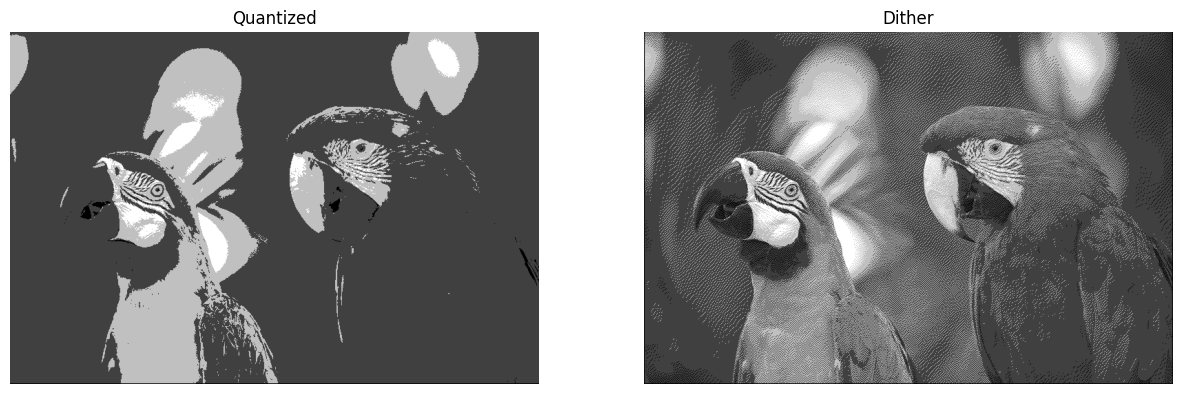

In [20]:
# Show quantized image (don't forget to cast back to uint8)
show_compare([quantized, dither], ["Quantized", "Dither"])
# plt.subplot(121), plt.imshow(quantized)   # optimally quantized
# plt.subplot(122), plt.imshow(dither)   # dithering

### Questions
* Which image has higher quantization error? Optimally quantized or dithered?
* Which image looks better to you?
* Can you repeat the same process using only two colours: black and white? Show me :-)

### Bonus Points

Repeat the homework using a diffrerent image pallette. For instance, you can use an optimal colour
pallette that we can calculate via k-means algorithm. The following snippet of code will give you the 16
optimal colours for your original image.

[[ 51.86900786]
 [187.79699897]]
[AVERAGE] MAE quant: 133.69257015652127
[AVERAGE] MAE dith: 132.11451975504556


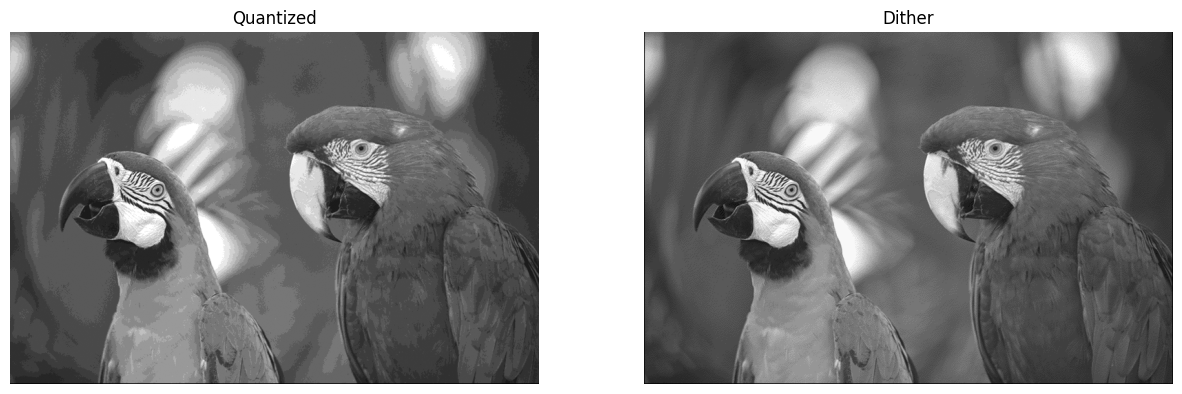

In [21]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=16).fit(np.reshape(img, (-1, 1)))
colors = kmeans.cluster_centers_
print(colors[:2])

quantized = quantization(img, colors)
dither = dithering(img, colors)

# Compute average quantization error
avg_quant_error = np.mean(np.abs(quantized - img))
print("[AVERAGE] MAE quant:", avg_quant_error)

# Compute average quantization error for dithered image
avg_dith_error = np.mean(np.abs(dither - img))
print("[AVERAGE] MAE dith:", avg_dith_error)

show_compare([quantized, dither], ["Quantized", "Dither"], {0: "gray", 1: "gray"})

[[182.53839651  60.78646206  52.85662267]
 [137.03292267 137.82081258 113.85247706]]
[AVERAGE] MAE quant: 125.85919698079427
[AVERAGE] MAE dith: 125.05865563286676


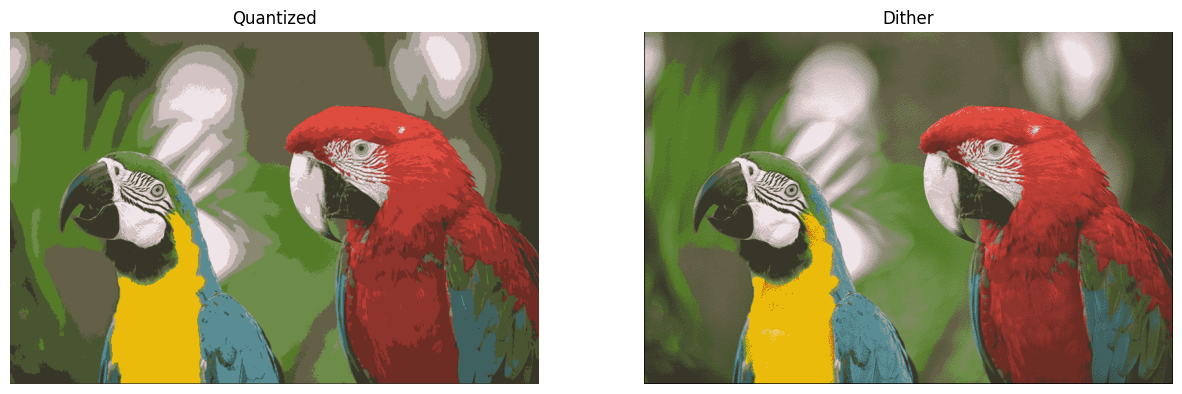

In [22]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=16).fit(np.reshape(img, (-1, 3)))
colors = kmeans.cluster_centers_
print(colors[:2])

quantized = quantization(img, colors)
dither = dithering(img, colors)

# Compute average quantization error
avg_quant_error = np.mean(np.abs(quantized - img))
print("[AVERAGE] MAE quant:", avg_quant_error)

# Compute average quantization error for dithered image
avg_dith_error = np.mean(np.abs(dither - img))
print("[AVERAGE] MAE dith:", avg_dith_error)

show_compare([quantized, dither], ["Quantized", "Dither"], {0: "gray", 1: "gray"})

Apply FS dithering the same way you did before.
* How does the result look like to you?
* What happens if we use 32 colours?
* And what happens if we use 256 colours?